In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("smartcart_customers.csv")

In [4]:
df["Income"]=df["Income"].fillna(df["Income"].median())
df["Age"]=2026-df["Year_Birth"]

In [5]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()

In [6]:
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [8]:
#Spending
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]


In [9]:
#Children
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [11]:
#Education
df["Education"].value_counts()
df["Education"]=df["Education"].replace({
    "Basic":"UnderGraduate","2n Cycle":"UnderGraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","PhD":"Postgraduate"})

In [12]:
#Marital_Status
df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"})
    

In [13]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
Spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop=cols+Spending_cols
df_cleaned=df.drop(columns=cols_to_drop)

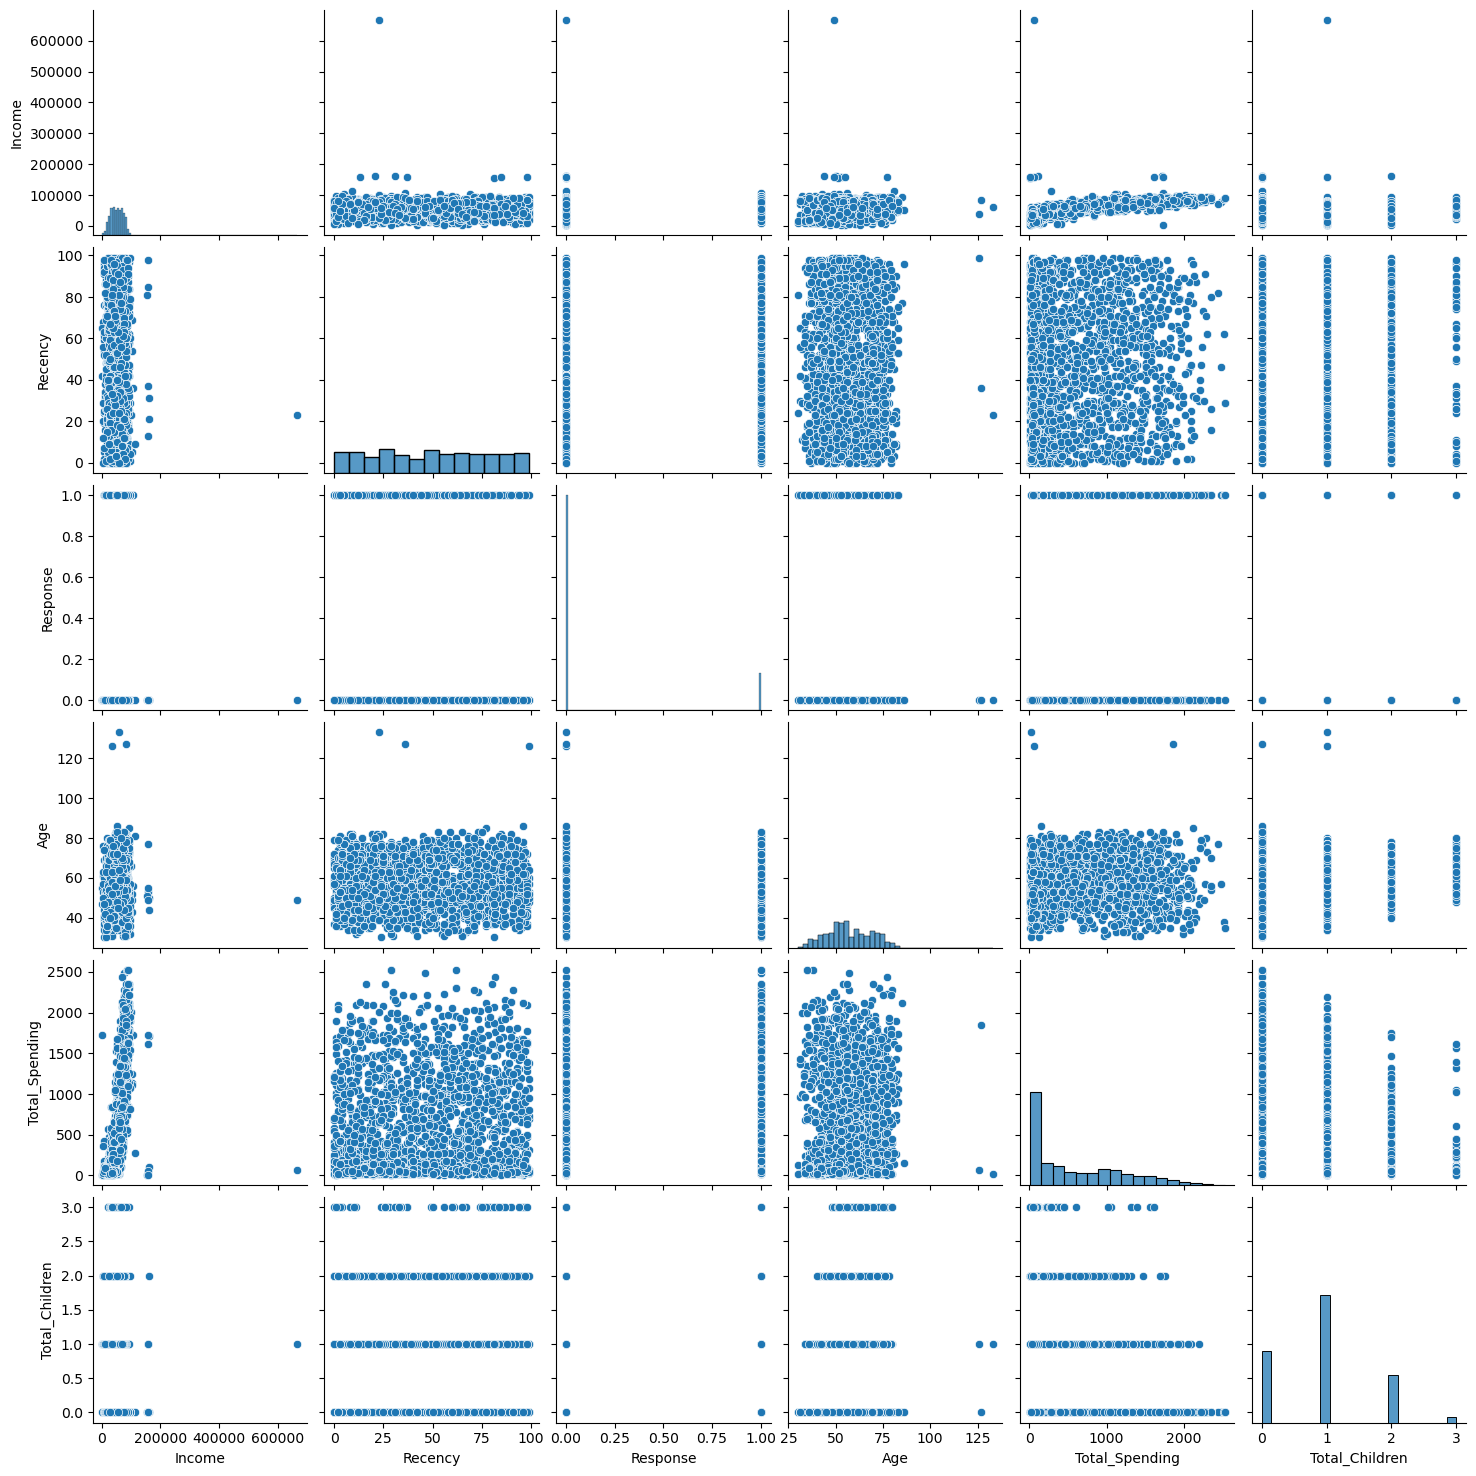

In [14]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [15]:
#Remove outliers
print("Data size with Outliers:",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("Data size with Outliers:",len(df_cleaned))

Data size with Outliers: 2240
Data size with Outliers: 2236


<Axes: >

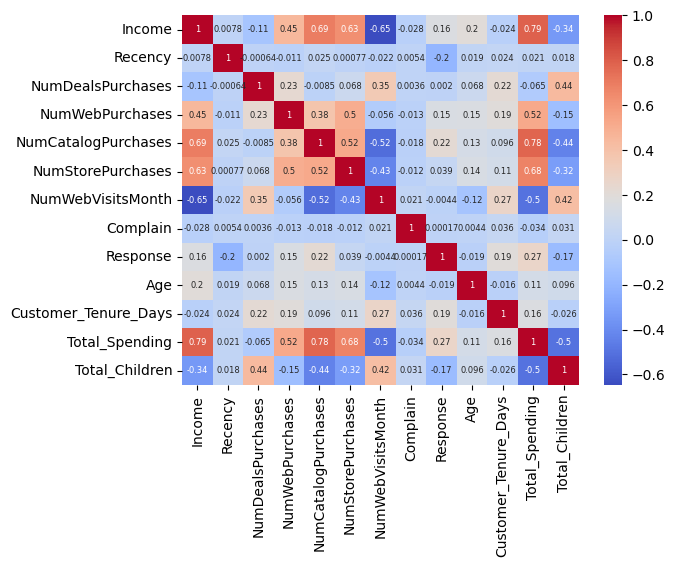

In [17]:
corr=df_cleaned.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,annot_kws={"size":6},cmap="coolwarm")

In [21]:
#Encoding
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Education","Living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [23]:
#Scaling
from sklearn.preprocessing import StandardScaler
x=df_encoded
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

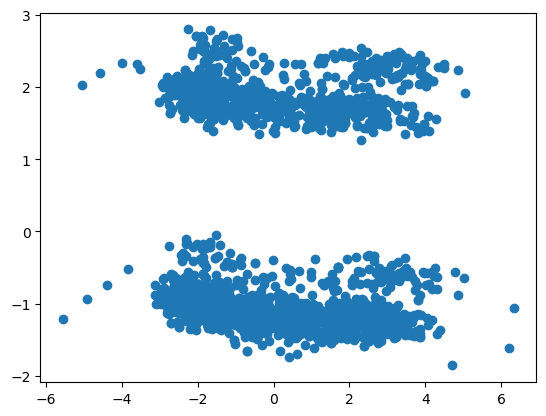

In [26]:
#Dimension Reduction
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)
plt.scatter(x_pca[:,0],x_pca[:,1])

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


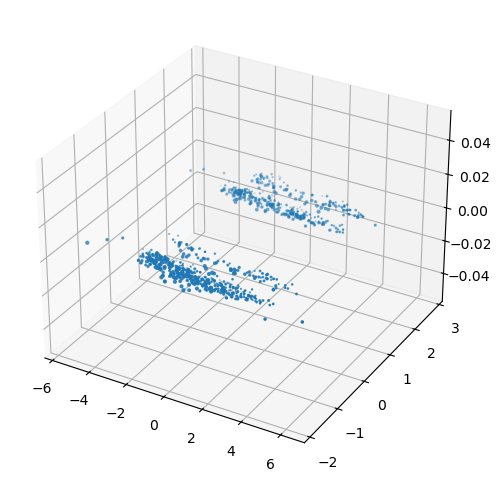

In [31]:
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
plt.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

In [57]:
#Analize K value 
#Elbow Method
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)
knee=KneeLocator(range(2,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow
print("best_k=",optimal_k)

best_k= 5


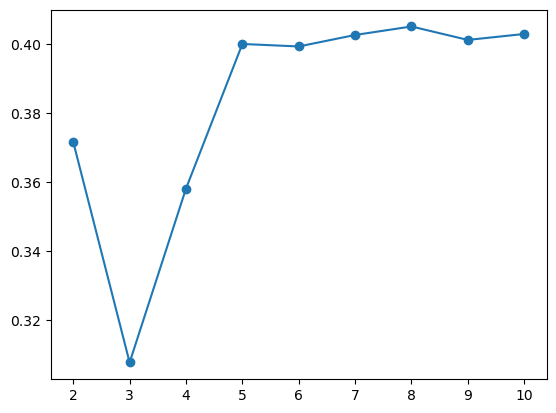

In [58]:
#Silhouette Score
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)
plt.plot(range(2,11),scores,marker='o')

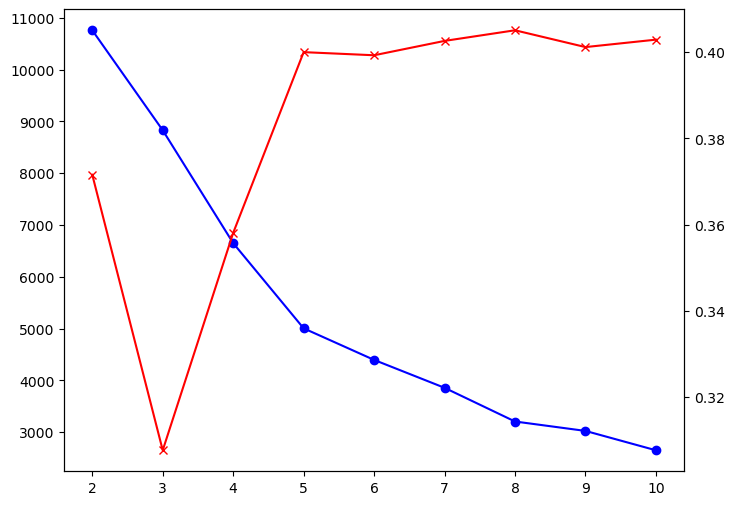

In [59]:
#Combined plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss,marker='o',color="blue")
ax2=ax1.twinx()
ax2.plot(k_range,scores,marker='x',color="red")

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


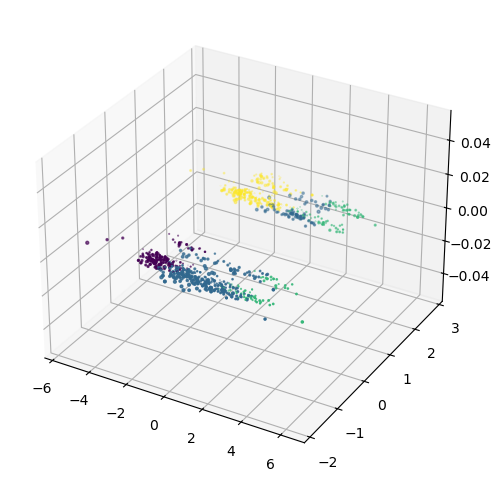

In [61]:
#Clustering
#Kmeans
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(x_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
plt.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


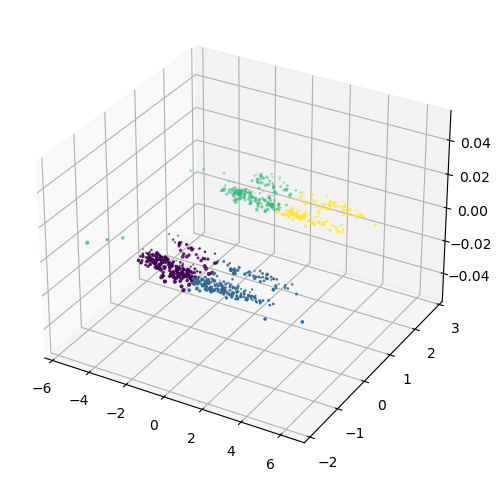

In [62]:
from sklearn.cluster import AgglomerativeClustering
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(x_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
plt.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)

<Axes: xlabel='cluster', ylabel='count'>

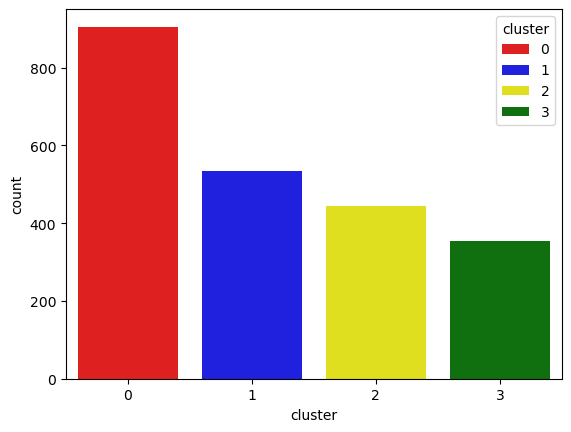

In [70]:
#Characterization of clusters
x["cluster"]=labels_agg
pal=["red","blue","yellow","green"]
sns.countplot(x=df_cleaned["cluster"],palette=pal,hue=df_cleaned["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

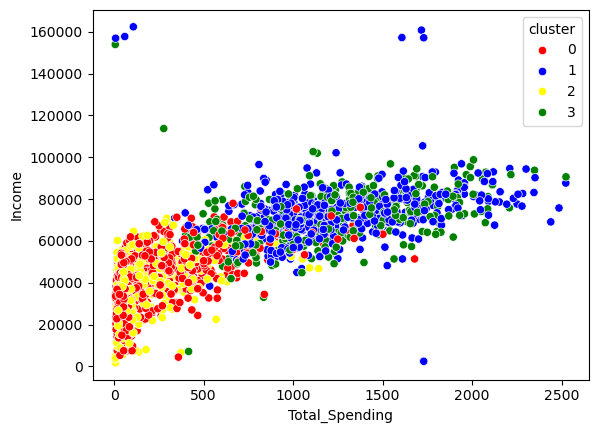

In [71]:
sns.scatterplot(x=x["Total_Spending"],y=x["Income"],palette=pal,hue=x["cluster"])

In [72]:
cluster_summary=x.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         